# 00_1 - Crear arrays preprocesados

Este notebook construye un dataset de arrays a partir de `xview_ann_train.json`. Lee todas las imagenes de entrenamiento una vez, guarda `X_all.npy` como `uint8` y conserva las etiquetas/metadatos asociados. El objetivo es reutilizar estos arrays en los notebooks de modelos y evitar abrir miles de `.tif` en cada experimento.


## Librerias y configuracion


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

print('Notebook para crear arrays. No necesita GPU.')


Notebook para crear arrays. No necesita GPU.


In [2]:
KAGGLE_INPUT_DIR = Path('/kaggle/input')
if not KAGGLE_INPUT_DIR.exists():
    raise FileNotFoundError('No existe /kaggle/input. Ejecuta este notebook en Kaggle.')

json_matches = sorted(KAGGLE_INPUT_DIR.rglob('xview_ann_train.json'))
if not json_matches:
    available_inputs = [p.name for p in KAGGLE_INPUT_DIR.iterdir() if p.is_dir()]
    raise FileNotFoundError(f'No se encontro xview_ann_train.json. Inputs disponibles: {available_inputs}')

ANN_JSON = json_matches[0]
DATA_ROOT = ANN_JSON.parent
TRAIN_DIR = DATA_ROOT / 'xview_train'
TEST_DIR = DATA_ROOT / 'xview_test'
WORKDIR = Path('/kaggle/working')

print('DATA_ROOT:', DATA_ROOT)
print('ANN_JSON:', ANN_JSON)
print('TRAIN_DIR exists:', TRAIN_DIR.exists())
print('TEST_DIR exists:', TEST_DIR.exists())


DATA_ROOT: /kaggle/input/datasets/eccvdl/xview-recognition
ANN_JSON: /kaggle/input/datasets/eccvdl/xview-recognition/xview_ann_train.json
TRAIN_DIR exists: True
TEST_DIR exists: True


## Datos


### Lectura del JSON


In [3]:
with open(ANN_JSON, 'r', encoding='utf-8') as f:
    json_data = json.load(f)

categories = {
    int(k): v['name']
    for k, v in sorted(json_data['categories'].items(), key=lambda item: int(item[0]))
}
category_names = list(categories.values())
category_to_idx = {name: idx for idx, name in categories.items()}

rows = []
for json_img, json_ann in zip(json_data['images'].values(), json_data['annotations'].values()):
    rows.append({
        'image_id': json_img['image_id'],
        'filename': json_img['filename'],
        'category': json_ann['category_id'],
        'label': category_to_idx[json_ann['category_id']],
        'width': json_img['width'],
        'height': json_img['height'],
        'exists': (DATA_ROOT / json_img['filename']).exists(),
    })

df = pd.DataFrame(rows)
print('Total imagenes:', len(df))
print('Archivos encontrados:', int(df['exists'].sum()))
df.head()


Total imagenes: 18746
Archivos encontrados: 18746


,image_id,filename,category,label,width,height,exists
0,0234476c-a017-4c9b-bd2f-872193076cca.tif,xview_train/Building/0234476c-a017-4c9b-bd2f-8...,Building,8,224,224,True
1,f2543073-9933-44c4-98e0-15eee2dffe2a.tif,xview_train/Building/f2543073-9933-44c4-98e0-1...,Building,8,224,224,True
2,6df5b6a5-82b0-4abb-8deb-7d7154c977bc.tif,xview_train/Building/6df5b6a5-82b0-4abb-8deb-7...,Building,8,224,224,True
3,ddbd2636-ce3c-4406-a5cf-92fa557dbd3c.tif,xview_train/Building/ddbd2636-ce3c-4406-a5cf-9...,Building,8,224,224,True
4,609064d1-3719-4163-ad36-577dab9805f0.tif,xview_train/Building/609064d1-3719-4163-ad36-5...,Building,8,224,224,True


category
Cargo plane            635
Small car             3324
Bus                   1768
Truck                 2210
Motorboat             1069
Fishing vessel         706
Dump truck            1236
Excavator              789
Building              3594
Helipad                111
Storage tank          1469
Shipping container    1523
Pylon                  312
Name: count, dtype: int64


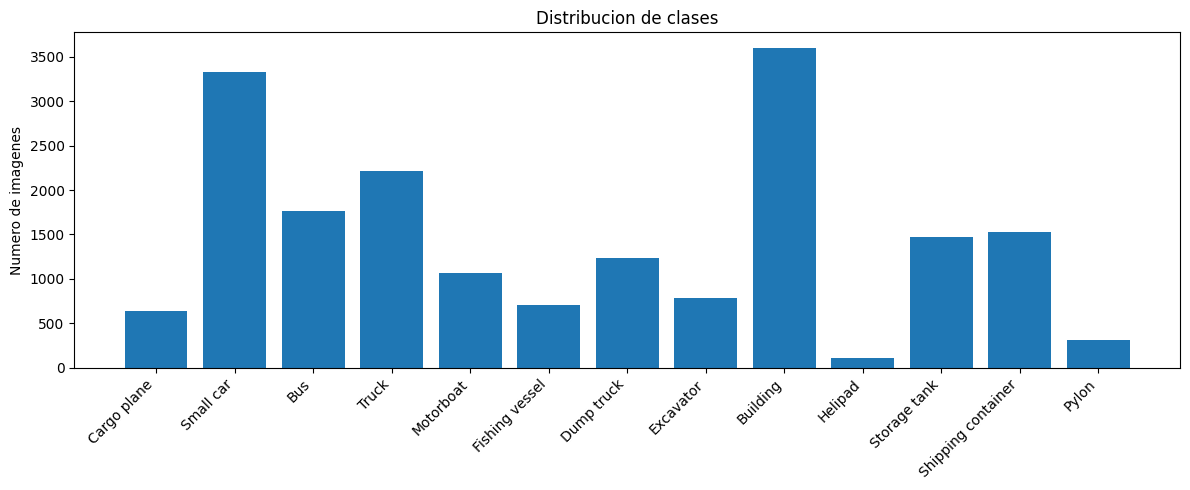

In [4]:
class_counts = df['category'].value_counts().reindex(category_names)
print(class_counts)

plt.figure(figsize=(12, 5))
plt.bar(class_counts.index, class_counts.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Numero de imagenes')
plt.title('Distribucion de clases')
plt.tight_layout()
plt.show()


### Comprobacion de una imagen


Filename: xview_train/Building/0234476c-a017-4c9b-bd2f-872193076cca.tif
Shape: (224, 224, 3)
Dtype: uint8
Min / Max: 0 86
Etiqueta: Building
Indice: 8
Primeros pixeles:
[[[45 30 19]
  [45 30 19]
  [46 30 19]]

 [[45 30 19]
  [45 30 19]
  [45 30 19]]

 [[45 30 19]
  [45 30 19]
  [45 30 19]]]


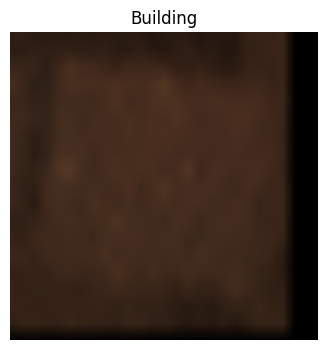

In [5]:
def load_image(filename):
    return np.array(Image.open(DATA_ROOT / filename).convert('RGB'))

sample = df.iloc[0]
img = load_image(sample['filename'])
print('Filename:', sample['filename'])
print('Shape:', img.shape)
print('Dtype:', img.dtype)
print('Min / Max:', img.min(), img.max())
print('Etiqueta:', sample['category'])
print('Indice:', sample['label'])
print('Primeros pixeles:')
print(img[:3, :3, :])

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title(sample['category'])
plt.axis('off')
plt.show()


## Construccion de arrays


In [6]:
OUT_DIR = WORKDIR / 'xview_arrays'
OUT_DIR.mkdir(parents=True, exist_ok=True)

X_path = OUT_DIR / 'X_all.npy'
y_path = OUT_DIR / 'y_all_idx.npy'
filenames_path = OUT_DIR / 'filenames.npy'
image_ids_path = OUT_DIR / 'image_ids.npy'
category_names_path = OUT_DIR / 'category_names.npy'
metadata_path = OUT_DIR / 'metadata.json'

print('OUT_DIR:', OUT_DIR)


OUT_DIR: /kaggle/working/xview_arrays


In [7]:
def build_arrays(data):
    n = len(data)
    X = np.empty((n, 224, 224, 3), dtype=np.uint8)
    y_idx = np.empty((n,), dtype=np.int32)
    filenames = np.empty((n,), dtype='U256')
    image_ids = np.empty((n,), dtype='U128')

    for i, row in enumerate(data.itertuples(index=False)):
        X[i] = load_image(row.filename)
        y_idx[i] = row.label
        filenames[i] = row.filename
        image_ids[i] = row.image_id

        if (i + 1) % 1000 == 0:
            print(f'Cargadas {i + 1}/{n} imagenes')

    return X, y_idx, filenames, image_ids

X_all, y_all_idx, filenames, image_ids = build_arrays(df)

print('X_all:', X_all.shape, X_all.dtype, 'RAM aprox:', X_all.nbytes / 1024**3, 'GB')
print('y_all_idx:', y_all_idx.shape, y_all_idx.dtype)
print('filenames:', filenames.shape, filenames.dtype)


Cargadas 1000/18746 imagenes
Cargadas 2000/18746 imagenes
Cargadas 3000/18746 imagenes
Cargadas 4000/18746 imagenes
Cargadas 5000/18746 imagenes
Cargadas 6000/18746 imagenes
Cargadas 7000/18746 imagenes
Cargadas 8000/18746 imagenes
Cargadas 9000/18746 imagenes
Cargadas 10000/18746 imagenes
Cargadas 11000/18746 imagenes
Cargadas 12000/18746 imagenes
Cargadas 13000/18746 imagenes
Cargadas 14000/18746 imagenes
Cargadas 15000/18746 imagenes
Cargadas 16000/18746 imagenes
Cargadas 17000/18746 imagenes
Cargadas 18000/18746 imagenes
X_all: (18746, 224, 224, 3) uint8 RAM aprox: 2.6280040740966797 GB
y_all_idx: (18746,) int32
filenames: (18746,) <U256


## Guardado


In [8]:
np.save(X_path, X_all)
np.save(y_path, y_all_idx)
np.save(filenames_path, filenames)
np.save(image_ids_path, image_ids)
np.save(category_names_path, np.array(category_names, dtype='U64'))

metadata = {
    'num_images': int(len(X_all)),
    'image_shape': list(X_all.shape[1:]),
    'x_dtype': str(X_all.dtype),
    'y_dtype': str(y_all_idx.dtype),
    'category_names': category_names,
    'category_to_idx': category_to_idx,
    'source_ann_json': str(ANN_JSON),
}
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

for p in [X_path, y_path, filenames_path, image_ids_path, category_names_path, metadata_path]:
    print(p, '-', p.stat().st_size / 1024**2, 'MB')


/kaggle/working/xview_arrays/X_all.npy - 2691.0762939453125 MB
/kaggle/working/xview_arrays/y_all_idx.npy - 0.07163238525390625 MB
/kaggle/working/xview_arrays/filenames.npy - 18.3067626953125 MB
/kaggle/working/xview_arrays/image_ids.npy - 9.1534423828125 MB
/kaggle/working/xview_arrays/category_names.npy - 0.0032958984375 MB
/kaggle/working/xview_arrays/metadata.json - 0.0007181167602539062 MB
